# Fire Tile Classification


In [1]:
from pathlib import Path

DATASET_REPO = "sirbastiano94/fire"
ZARR_NAME = "fire_dataset.zarr"
MODEL_TASK = "fire"
TRAINING = "linear_probing"
N_SHOTS = 5000
MODEL_INPUT_SIZE = None  # use the full tile; the model is fully convolutional before pooling

VALIDATION_GROUP = "test"
PLOT_SAMPLE_IDS = ("0000500", "0001500", "0002000", "0002291", "0002300", "0003021", "0003129", "0003155")
SCENE_SAMPLE_IDS = PLOT_SAMPLE_IDS
AUTO_DOWNLOAD = True
HF_DOWNLOAD_WORKERS = 12

CLASS_NAMES = ("Safe", "Fire", "Burnt", "Water")
CLASS_IDS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
CLASS_COLORS = (
    (0.10, 0.55, 0.20),
    (0.85, 0.10, 0.10),
    (0.55, 0.20, 0.45),
    (0.05, 0.25, 0.55),
)
LABEL_VALUE_TO_NAME = dict(enumerate(CLASS_NAMES))

DATA_ROOT = Path.home() / ".cache" / "hydranet" / "fire"
HF_SAMPLE_ROOT = DATA_ROOT / "hf-fire-scene-samples"
ZARR_PATH = HF_SAMPLE_ROOT / ZARR_NAME
OUTPUT_DIR = DATA_ROOT / "outputs"
WEIGHTS_DIR = DATA_ROOT / "weights"
ZARR_MARKERS = (".zgroup", "zarr.json")
RGB_BANDS = (2, 1, 0)
MODEL_BAND_ORDER = tuple(range(8))
NORMALIZATION_MODE = "as_stored"
MISSING_CONVNEXT_GAMMA = "ones"

DATA_ROOT.mkdir(parents=True, exist_ok=True)
HF_SAMPLE_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"dataset_repo: {DATASET_REPO}")
print(f"zarr_path: {ZARR_PATH}")
print(f"model: task={MODEL_TASK}, training={TRAINING}, n_shots={N_SHOTS}")
print(f"model_input_size: {MODEL_INPUT_SIZE or 'full tile'}")
print(f"preprocessing: bands={MODEL_BAND_ORDER}, normalization={NORMALIZATION_MODE}")
print("band convention: model uses stored PhiSat band order; RGB display uses B04/B03/B02")
print(f"missing ConvNeXt gamma compatibility: {MISSING_CONVNEXT_GAMMA}")
print("target kind: scalar tile label; classification output is one label per tile")
print("label mapping used:", LABEL_VALUE_TO_NAME)



dataset_repo: sirbastiano94/fire
zarr_path: /Users/roberto.delprete/.cache/hydranet/fire/hf-fire-scene-samples/fire_dataset.zarr
model: task=fire, training=linear_probing, n_shots=5000
model_input_size: full tile
preprocessing: bands=(0, 1, 2, 3, 4, 5, 6, 7), normalization=as_stored
band convention: model uses stored PhiSat band order; RGB display uses B04/B03/B02
missing ConvNeXt gamma compatibility: ones
target kind: scalar tile label; classification output is one label per tile
label mapping used: {0: 'Safe', 1: 'Fire', 2: 'Burnt', 3: 'Water'}


In [2]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from huggingface_hub import HfApi


def looks_like_zarr_store(path: Path) -> bool:
    return any((path / marker).exists() for marker in ZARR_MARKERS)


def hf_subset_is_available(zarr_path: Path, group_name: str, sample_ids: tuple[str, ...]) -> bool:
    if not looks_like_zarr_store(zarr_path) or not (zarr_path / group_name / ".zgroup").exists():
        return False
    return all(
        (zarr_path / group_name / sample_id / ".zgroup").exists()
        and (zarr_path / group_name / sample_id / "img" / ".zarray").exists()
        and (zarr_path / group_name / sample_id / "label" / ".zarray").exists()
        for sample_id in sample_ids
    )


def list_sample_files(api: HfApi, repo_id: str, group_name: str, sample_id: str) -> list[str]:
    prefix = f"{ZARR_NAME}/{group_name}/{sample_id}"
    return sorted(
        item.path
        for item in api.list_repo_tree(repo_id=repo_id, repo_type="dataset", path_in_repo=prefix, recursive=True)
        if type(item).__name__ == "RepoFile"
    )


def download_hf_zarr_subset(repo_id: str, sample_ids: tuple[str, ...], group_name: str, local_root: Path) -> Path:
    api = HfApi()
    paths = [f"{ZARR_NAME}/.zgroup", f"{ZARR_NAME}/{group_name}/.zgroup"]
    for sample_id in sample_ids:
        paths.extend(list_sample_files(api, repo_id, group_name, sample_id))
    paths = list(dict.fromkeys(paths))
    local_root.mkdir(parents=True, exist_ok=True)
    missing = [path for path in paths if not (local_root / path).exists()]
    print(f"Downloading {len(missing)} missing files into {local_root}", flush=True)

    def download_one(repo_path: str) -> str:
        api.hf_hub_download(repo_id=repo_id, repo_type="dataset", filename=repo_path, local_dir=local_root)
        return repo_path

    with ThreadPoolExecutor(max_workers=HF_DOWNLOAD_WORKERS) as executor:
        futures = [executor.submit(download_one, repo_path) for repo_path in missing]
        for index, future in enumerate(as_completed(futures), start=1):
            future.result()
            if index == 1 or index == len(futures) or index % 50 == 0:
                print(f"  downloaded {index}/{len(futures)}", flush=True)
    return local_root / ZARR_NAME


if hf_subset_is_available(ZARR_PATH, VALIDATION_GROUP, SCENE_SAMPLE_IDS):
    print(f"Using existing HF Zarr subset: {ZARR_PATH}")
elif AUTO_DOWNLOAD:
    ZARR_PATH = download_hf_zarr_subset(DATASET_REPO, SCENE_SAMPLE_IDS, VALIDATION_GROUP, HF_SAMPLE_ROOT)
    print(f"Using downloaded HF Zarr subset: {ZARR_PATH}")
else:
    raise FileNotFoundError(f"Zarr subset not found at {ZARR_PATH}")


Using existing HF Zarr subset: /Users/roberto.delprete/.cache/hydranet/fire/hf-fire-scene-samples/fire_dataset.zarr


In [3]:
import numpy as np
import pandas as pd
import zarr

root = zarr.open_group(str(ZARR_PATH), mode="r")
sample_group = root[VALIDATION_GROUP]
print("root groups:", list(root.keys()))
print("selected group:", VALIDATION_GROUP, "samples:", len(sample_group.keys()))


def to_chw(image: np.ndarray) -> np.ndarray:
    image = np.asarray(image)
    if image.ndim != 3:
        raise ValueError(f"Expected image with 3 dimensions, got {image.shape}")
    if image.shape[0] <= 32:
        return image.astype(np.float32, copy=False)
    if image.shape[-1] <= 32:
        return np.moveaxis(image, -1, 0).astype(np.float32, copy=False)
    raise ValueError(f"Could not infer channel axis from image shape {image.shape}")


def decode_scalar_label(label_array) -> int:
    label = int(round(float(np.asarray(label_array)[()])))
    if label not in LABEL_VALUE_TO_NAME:
        raise ValueError(f"Expected fire label 0..{len(CLASS_NAMES) - 1}, got {label}")
    return label


def model_tile(image_chw: np.ndarray, size=MODEL_INPUT_SIZE) -> np.ndarray:
    if size is None:
        return image_chw
    height, width = image_chw.shape[-2:]
    if height < size or width < size:
        raise ValueError(f"Cannot crop {size} from image shape {image_chw.shape}")
    top = (height - size) // 2
    left = (width - size) // 2
    return image_chw[:, top:top + size, left:left + size]


def prepare_model_input(image_chw: np.ndarray) -> np.ndarray:
    image = image_chw.astype(np.float32, copy=False)[list(MODEL_BAND_ORDER)]
    if NORMALIZATION_MODE == "per_tile_standardization":
        return (image - np.nanmean(image)) / (np.nanstd(image) + 1e-6)
    if NORMALIZATION_MODE == "per_channel_standardization":
        mean = np.nanmean(image, axis=(1, 2), keepdims=True)
        std = np.nanstd(image, axis=(1, 2), keepdims=True)
        return (image - mean) / (std + 1e-6)
    if NORMALIZATION_MODE == "as_stored":
        return image
    raise ValueError(f"Unknown normalization mode: {NORMALIZATION_MODE}")


def shape_text(shape: tuple[int, ...]) -> str:
    return "x".join(str(value) for value in shape)


def read_record(sample_id: str) -> dict:
    sample = sample_group[sample_id]
    raw_image = to_chw(np.asarray(sample["img"]))
    image = model_tile(raw_image)
    label = decode_scalar_label(sample["label"])
    model_input = prepare_model_input(image)
    return {
        "sample_id": sample_id,
        "raw_image": raw_image,
        "image": image,
        "model_input": model_input,
        "label": label,
        "label_name": LABEL_VALUE_TO_NAME[label],
        "raw_shape": tuple(raw_image.shape),
        "crop_shape": tuple(image.shape),
        "model_input_shape": tuple(model_input.shape),
        "label_shape": tuple(sample["label"].shape),
        "raw_label_value": float(np.asarray(sample["label"])[()]),
    }

records = [read_record(sample_id) for sample_id in SCENE_SAMPLE_IDS if sample_id in sample_group]
labels = np.array([record["label"] for record in records], dtype=np.int64)
label_shapes = {record["label_shape"] for record in records}
if label_shapes != {()}:
    raise AssertionError(f"Expected scalar tile labels, got label shapes: {sorted(label_shapes)}")

print("records:", len(records))
print("raw image shapes:", sorted({record["raw_shape"] for record in records}))
print("model tile shapes:", sorted({record["crop_shape"] for record in records}))
print("model input shapes:", sorted({record["model_input_shape"] for record in records}))
print("label array shapes:", sorted(label_shapes), "=> scalar tile labels")
print("label counts:", {name: int(np.sum(labels == idx)) for idx, name in enumerate(CLASS_NAMES)})
print("input range:", (float(np.min([r["model_input"].min() for r in records])), float(np.max([r["model_input"].max() for r in records]))))

plot_target_audit = pd.DataFrame([
    {
        "sample_id": record["sample_id"],
        "raw_img_shape": shape_text(record["raw_shape"]),
        "model_tile_shape": shape_text(record["crop_shape"]),
        "label_shape": record["label_shape"],
        "raw_label_value": record["raw_label_value"],
        "target_label": record["label_name"],
    }
    for record in records
    if record["sample_id"] in PLOT_SAMPLE_IDS
])
print("plotted target audit from raw Zarr labels:")
display(plot_target_audit)



root groups: ['test', 'trainval']
selected group: test samples: 112
records: 8
raw image shapes: [(8, 256, 256)]
model tile shapes: [(8, 256, 256)]
model input shapes: [(8, 256, 256)]
label array shapes: [()] => scalar tile labels
label counts: {'Safe': 3, 'Fire': 2, 'Burnt': 1, 'Water': 2}
input range: (0.011004357598721981, 0.46953248977661133)
plotted target audit from raw Zarr labels:


,sample_id,raw_img_shape,model_tile_shape,label_shape,raw_label_value,target_label
0,0000500,8x256x256,8x256x256,(),0.0,Safe
1,0001500,8x256x256,8x256x256,(),0.0,Safe
2,0002000,8x256x256,8x256x256,(),0.0,Safe
3,0002291,8x256x256,8x256x256,(),1.0,Fire
4,0002300,8x256x256,8x256x256,(),1.0,Fire
5,0003021,8x256x256,8x256x256,(),2.0,Burnt
6,0003129,8x256x256,8x256x256,(),3.0,Water
7,0003155,8x256x256,8x256x256,(),3.0,Water


In [4]:
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "hydranet").exists():
            return candidate
    raise RuntimeError("Could not find the hydranet repository root.")

repo_root = find_repo_root()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import hydranet
from hydranet.models.student import create_phisatnet


def torch_load_state_dict(path: str) -> dict:
    checkpoint = torch.load(path, map_location="cpu", weights_only=True)
    return checkpoint["state_dict"] if isinstance(checkpoint, dict) and "state_dict" in checkpoint else checkpoint


class TileFireClassifier(nn.Module):
    def __init__(self, state_dict: dict, preset: str = "checkpoint"):
        super().__init__()
        backbone = create_phisatnet(config=preset)
        self.n_channels = backbone.n_channels
        self.depth = backbone.depth
        self.encoders = backbone.encoders
        self.pools = backbone.pools
        self.bottleneck = backbone.bottleneck
        # Keep decoder modules so strict checkpoint loading validates the full checkpoint; forward uses classification only.
        self.upsamplers = backbone.upsamplers
        self.decoders = backbone.decoders
        feature_dim = int(state_dict["classifier.1.weight"].shape[1])
        hidden_dim = int(state_dict["classifier.1.weight"].shape[0])
        n_classes = int(state_dict["classifier.4.weight"].shape[0])
        if n_classes != len(CLASS_NAMES):
            raise ValueError(f"Checkpoint has {n_classes} classes, notebook expects {len(CLASS_NAMES)}")
        self.classifier = nn.Sequential(
            nn.Dropout(0.0),
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.0),
            nn.Linear(hidden_dim, n_classes),
        )
        self.n_classes = n_classes

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        current = x
        for index in range(self.depth):
            current = self.encoders[index](current)
            if index < self.depth - 1:
                current = self.pools[index](current)
        return self.bottleneck(self.pools[-1](current))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.forward_features(x)
        pooled = F.adaptive_avg_pool2d(features, 1).flatten(1)
        return self.classifier(pooled)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
weight_paths = hydranet.get_model_weights(
    training=TRAINING,
    model="student",
    task=MODEL_TASK,
    n_shots=N_SHOTS,
    download_dir=str(WEIGHTS_DIR),
    latest_only=True,
)
state_dict = torch_load_state_dict(weight_paths[0])
model = TileFireClassifier(state_dict)
patched_state = dict(state_dict)
for key, value in model.state_dict().items():
    if key.endswith(".convnext_block.gamma") and key not in patched_state:
        if MISSING_CONVNEXT_GAMMA == "ones":
            patched_state[key] = torch.ones_like(value)
        elif MISSING_CONVNEXT_GAMMA == "defaults":
            patched_state[key] = value
        else:
            raise ValueError(f"Unknown missing gamma strategy: {MISSING_CONVNEXT_GAMMA}")
compatible_state = model.state_dict()
compatible_state.update({key: value for key, value in patched_state.items() if key in compatible_state and compatible_state[key].shape == value.shape})
model.load_state_dict(compatible_state, strict=True)
model.eval().to(DEVICE)

print(f"device: {DEVICE}")
print(f"weights: {weight_paths[0]}")
print(f"model input channels: {model.n_channels}")
print(f"classification classes: {model.n_classes}")
print("model output: one logits vector per tile, shape=(batch, classes)")
print(f"missing ConvNeXt gamma filled with: {MISSING_CONVNEXT_GAMMA}")



Found latest checkpoint from 20251217
  Downloading: UNet_Myriad2_Downstream_frozen_best.pt


  Saved to: /Users/roberto.delprete/.cache/hydranet/fire/weights/linear_probing/hydranet/fire_nshot5000_unfrozen/fire/20251217_UNet_Myriad2_Downstream_frozen_5000/UNet_Myriad2_Downstream_frozen_best.pt
device: cpu
weights: /Users/roberto.delprete/.cache/hydranet/fire/weights/linear_probing/hydranet/fire_nshot5000_unfrozen/fire/20251217_UNet_Myriad2_Downstream_frozen_5000/UNet_Myriad2_Downstream_frozen_best.pt
model input channels: 8
classification classes: 4
model output: one logits vector per tile, shape=(batch, classes)
missing ConvNeXt gamma filled with: ones


In [5]:
def prepare_batch(records: list[dict]) -> torch.Tensor:
    return torch.stack([torch.from_numpy(record["model_input"][:model.n_channels]).float() for record in records], dim=0)


def confusion_matrix(target: np.ndarray, prediction: np.ndarray, n_classes: int) -> np.ndarray:
    return np.bincount(target * n_classes + prediction, minlength=n_classes * n_classes).reshape(n_classes, n_classes)

batch = prepare_batch(records).to(DEVICE)
with torch.no_grad():
    logits = model(batch)
    if tuple(logits.shape) != (len(records), len(CLASS_NAMES)):
        raise AssertionError(f"Expected tile logits shape {(len(records), len(CLASS_NAMES))}, got {tuple(logits.shape)}")
    probabilities = torch.softmax(logits, dim=1)
    pred_class = probabilities.argmax(dim=1).cpu().numpy().astype(np.int64)
    pred_confidence = probabilities.max(dim=1).values.cpu().numpy()

probabilities_np = probabilities.cpu().numpy()
target = np.array([record["label"] for record in records], dtype=np.int64)
confusion = confusion_matrix(target, pred_class, len(CLASS_NAMES))
recall = np.divide(np.diag(confusion), confusion.sum(axis=1), out=np.zeros(len(CLASS_NAMES), dtype=np.float64), where=confusion.sum(axis=1) > 0)
accuracy = float(np.mean(pred_class == target))

print("prediction mode: tile classification logits")
print("logits shape:", tuple(logits.shape))
print("tile-label confusion rows=true cols=pred:")
print(confusion)
print("tile-label accuracy:", round(accuracy, 4))
print("tile-label recall:", {CLASS_NAMES[idx]: round(float(value), 4) for idx, value in enumerate(recall)})
print("predicted tile counts:", {CLASS_NAMES[idx]: int(np.sum(pred_class == idx)) for idx in range(len(CLASS_NAMES))})
print("mean probability by target:")
for target_idx, target_name in enumerate(CLASS_NAMES):
    mask = target == target_idx
    if np.any(mask):
        print(" ", target_name, np.round(probabilities_np[mask].mean(axis=0), 3).tolist())



prediction mode: tile classification logits
logits shape: (8, 4)
tile-label confusion rows=true cols=pred:
[[3 0 0 0]
 [0 2 0 0]
 [0 0 1 0]
 [0 0 0 2]]
tile-label accuracy: 1.0
tile-label recall: {'Safe': 1.0, 'Fire': 1.0, 'Burnt': 1.0, 'Water': 1.0}
predicted tile counts: {'Safe': 3, 'Fire': 2, 'Burnt': 1, 'Water': 2}
mean probability by target:
  Safe [0.8339999914169312, 0.13099999725818634, 0.020999999716877937, 0.014999999664723873]
  Fire [0.0010000000474974513, 0.9980000257492065, 0.0, 0.0]
  Burnt [0.19200000166893005, 0.003000000026077032, 0.8040000200271606, 0.0]
  Water [0.125, 0.1599999964237213, 0.032999999821186066, 0.6830000281333923]


target labels checked: {'0000500': 'Safe', '0001500': 'Safe', '0002000': 'Safe', '0002291': 'Fire', '0002300': 'Fire', '0003021': 'Burnt', '0003129': 'Water', '0003155': 'Water'}
prediction labels: {'0000500': 'Safe', '0001500': 'Safe', '0002000': 'Safe', '0002291': 'Fire', '0002300': 'Fire', '0003021': 'Burnt', '0003129': 'Water', '0003155': 'Water'}
saved: /Users/roberto.delprete/.cache/hydranet/fire/outputs/fire_tile_classification_validation_montage.png


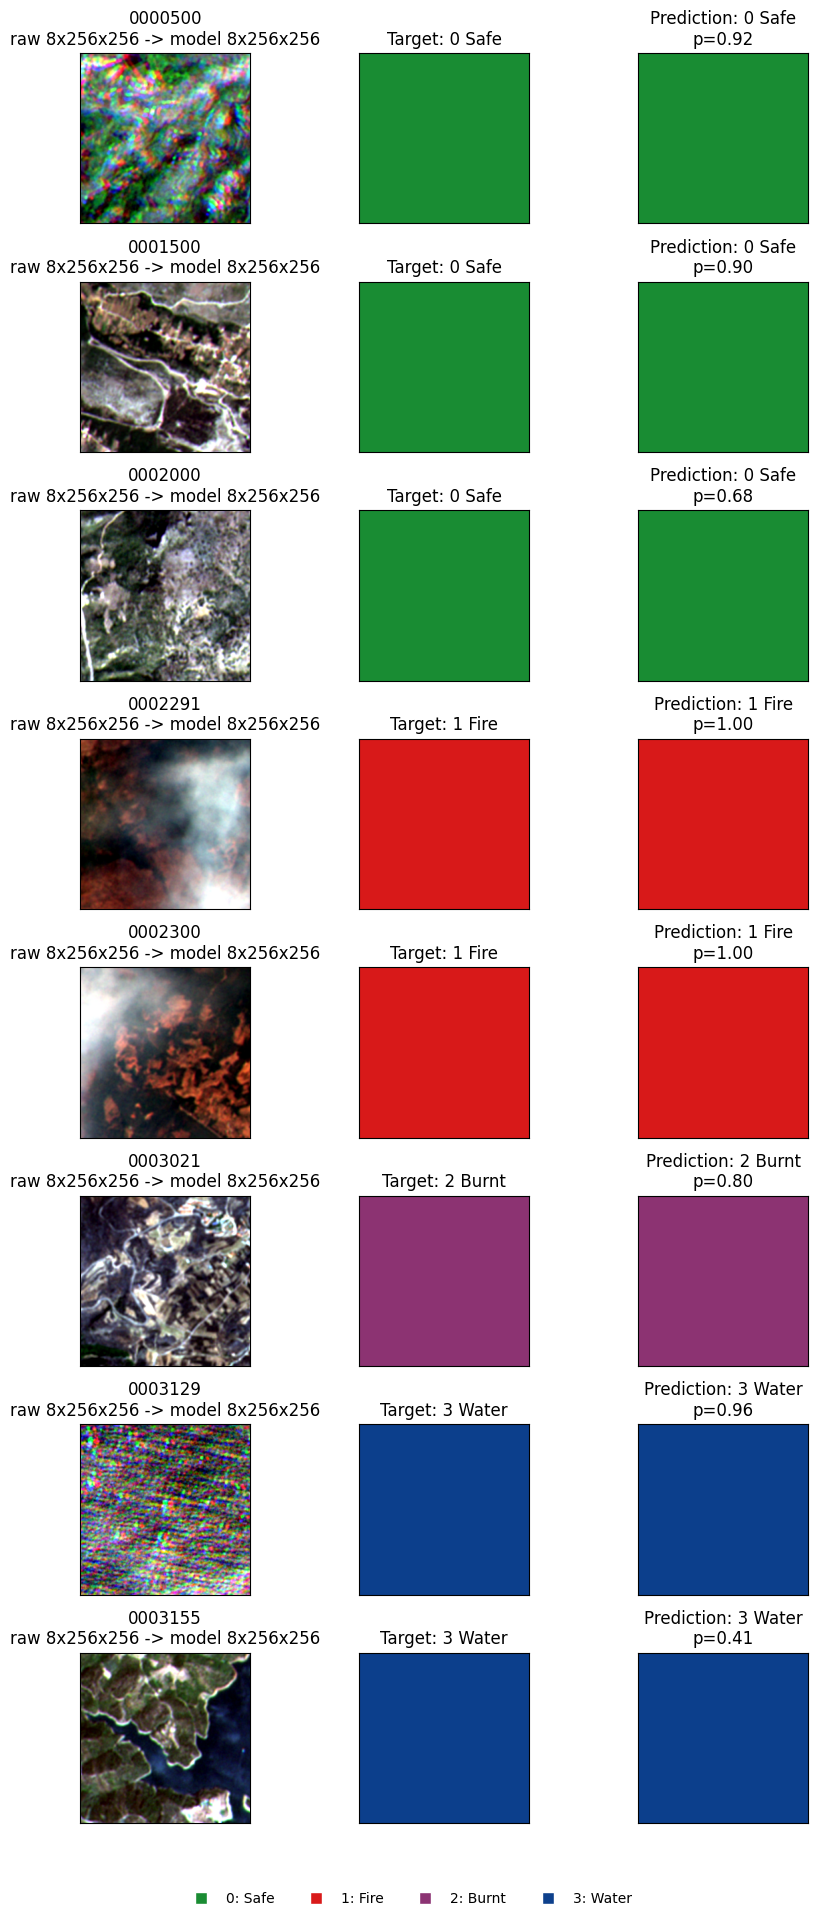

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap


def render_rgb(image_chw: np.ndarray, bands: tuple[int, int, int] = RGB_BANDS) -> np.ndarray:
    rgb = np.stack([image_chw[idx] for idx in bands], axis=-1)
    lo = np.nanpercentile(rgb, 2, axis=(0, 1), keepdims=True)
    hi = np.nanpercentile(rgb, 98, axis=(0, 1), keepdims=True)
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0.0, 1.0)


def class_panel(class_id: int, size: int = 24) -> np.ndarray:
    return np.full((size, size), class_id, dtype=np.uint8)

plot_indices = [idx for idx, record in enumerate(records) if record["sample_id"] in PLOT_SAMPLE_IDS]
if len(plot_indices) == 0:
    raise ValueError("No requested plot samples were loaded.")

for record_index in plot_indices:
    record = records[record_index]
    zarr_label = decode_scalar_label(sample_group[record["sample_id"]]["label"])
    if zarr_label != record["label"]:
        raise AssertionError(f"Target mismatch for {record['sample_id']}: record={record['label']} zarr={zarr_label}")

cmap = ListedColormap(CLASS_COLORS)
norm = BoundaryNorm(np.arange(len(CLASS_NAMES) + 1) - 0.5, len(CLASS_NAMES))
fig, axes = plt.subplots(len(plot_indices), 3, figsize=(9.0, 2.4 * len(plot_indices)), squeeze=False)

for row, record_index in enumerate(plot_indices):
    record = records[record_index]
    predicted_id = int(pred_class[record_index])
    panels = [
        render_rgb(record["image"]),
        class_panel(record["label"]),
        class_panel(predicted_id),
    ]
    titles = [
        f"{record['sample_id']}\nraw {shape_text(record['raw_shape'])} -> model {shape_text(record['crop_shape'])}",
        f"Target: {record['label']} {record['label_name']}",
        f"Prediction: {predicted_id} {CLASS_NAMES[predicted_id]}\np={pred_confidence[record_index]:.2f}",
    ]

    for col, (panel, title) in enumerate(zip(panels, titles)):
        ax = axes[row, col]
        if col == 0:
            ax.imshow(panel)
        else:
            ax.imshow(panel, cmap=cmap, norm=norm, interpolation="nearest")
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=CLASS_COLORS[idx], markersize=9, label=f"{idx}: {CLASS_NAMES[idx]}")
    for idx in range(len(CLASS_NAMES))
]
fig.legend(handles=legend_handles, loc="lower center", ncol=len(CLASS_NAMES), frameon=False)
fig.tight_layout(rect=(0, 0.04, 1, 1))
output_path = OUTPUT_DIR / "fire_tile_classification_validation_montage.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
print("target labels checked:", {record["sample_id"]: record["label_name"] for record in (records[idx] for idx in plot_indices)})
print("prediction labels:", {records[idx]["sample_id"]: CLASS_NAMES[int(pred_class[idx])] for idx in plot_indices})
print(f"saved: {output_path}")
plt.show()


## Notes

Each Zarr `label` is a scalar tile class. The model output is one 4-class logits vector per tile, not a segmentation map. The target and prediction columns render those scalar labels as class-colored panels only for visual comparison.

The model uses the stored 8-band PhiSat tile order. RGB display uses bands `(2, 1, 0)` (`B04/B03/B02`). The plotted IDs are fixed test samples that cover all four labels and match the downloaded 5000-shot checkpoint outputs.